# ER Diagram

<!-- <img src="er_diagram.png" alt="ER diagram" width="400" height="200">
<p align="center"><img src="image.png" alt="Centered image"></p> -->

The ER diagram does not include everything, it includes the most common subset used. Full description at https://aisynphys.readthedocs.io/en/current-release/api_schema.html#api-schema

![ER Diagram](er_diagram.png "ER diagram")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
import pyqtgraph
print(pyqtgraph.__file__)
import neuroanalysis
print(neuroanalysis.__file__)
import neuroanalysis.util
import aisynphys
import aisynphys.database
print(aisynphys.__file__)

from IPython.display import display, Markdown

c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\pyqtgraph\__init__.py
C:\Users\snrambo\neuroanalysis\neuroanalysis\__init__.py
C:\Users\snrambo\aisynphys\aisynphys\__init__.py


# Set up DB connection

To get this working, I have:
* Downloaded aisynphys source code
* Downloaded neuroanalysis source code
* Set up environment in anaconda, with python 3.9:

```powershell
# clone repo aisynphys
# change to python 3.9 in yaml
mamba create -n aisynphys39 python=3.9
conda activate aisynphys39
mamba install numpy scipy pandas matplotlib sqlalchemy pyqt pyqtgraph numba h5py -c conda-forge
pip install lmfit
cd C:\Users\myuser\src\aisynphys
python setup.py develop
# cd to user
git clone https://github.com/alleninstitute/neuroanalysis
cd C:\Users\myuser\neuroanalysis
python setup.py develop
# Then was a problem with missing pyyaml, so downloaded that
mamba install -c conda-forge pyyaml
```

In [2]:
from aisynphys.database import SynphysDatabase # https://aisynphys.readthedocs.io/en/current-release/database_access.html#database-access
from pathlib import Path

# Define cache directory
CACHE_PATH = Path("data/aisynphys/cache").resolve()

# Create a cache directory if it does not exist
CACHE_PATH.mkdir(parents=True, exist_ok=True)

# Tell AISynPhys to use this cache
aisynphys.config.cache_path = CACHE_PATH
# SynphysDatabase.set_cache_path(CACHE_PATH)


# Make cache
DATA_ROOT = Path("data/aisynphys/cache")

# Inspect available database versions
SynphysDatabase.list_versions()  # List all available versions

# Load small database -- Uncomment to load
# DB_VERSION = 'synphys_r2.1_medium.sqlite'
# db = SynphysDatabase.load_version(DB_VERSION)

[{'db_file': 'synphys_r1.0_2019-08-29_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_2019-08-29_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_2019-08-29_full.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_full.sqlite',
  'schema_

In [3]:
# Get file path and ensure it exist
DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_medium.sqlite').resolve()  # database

assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"

In [4]:
# Create SQLite connection to SQLite database

con = sqlite3.connect(DB_PATH)  # Create a connection object that "connects to the database"
cur = con.cursor()  # database cursor

# Table overview

In [5]:
table_list = cur.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()

for i, name in enumerate(table_list):
    print(i, name[0])


# Because they are stored in the form of ('pair',), accessing them by (str(list[i])[2:-3]) displays from the third index which is the first letter (excluding "('" ), and excluding the last "',)"
print(f"{str(table_list[9])[2:-3]}\n{str(table_list[20])[2:-3]}")

0 metadata
1 pipeline
2 slice
3 experiment
4 electrode
5 sync_rec
6 cortical_site
7 cell
8 recording
9 pair
10 intrinsic
11 morphology
12 test_pulse
13 stim_pulse
14 baseline
15 cortical_cell_location
16 patch_seq
17 patch_clamp_recording
18 stim_spike
19 pulse_response
20 synapse
21 poly_synapse
22 dynamics
23 synapse_prediction
24 gap_junction
25 synapse_model
26 multi_patch_probe
27 avg_response_fit
28 pulse_response_fit
29 pulse_response_strength
30 resting_state_fit
31 conductance
pair
synapse


# Formatting for figures

In [6]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 16,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

# Explore tables

In [7]:
query = """
            SELECT DISTINCT qual_morpho_type FROM morphology
        """

df = pd.read_sql_query(query, con)

df

,qual_morpho_type
0,None
1,L2/3 IT cell
2,L5 IT
3,L6a non-tuffed/simple tuft
4,Martinotti Cell
5,Martinotti cell
6,"Tufted L4,5"
7,bipolar
8,bipolar cell
9,bipolar cell?


In [7]:
query = """
            SELECT DISTINCT target_region FROM experiment
        """

df = pd.read_sql_query(query, con)

df

,target_region
0,VisP
1,ALM
2,TCx
3,FCx
4,None
5,
6,PCx
7,TEa
8,ACC
9,OCx


In [8]:
query = """
            SELECT DISTINCT species FROM slice
        """

df = pd.read_sql_query(query, con)

df

,species
0,mouse
1,human



VisP: Primary Visual Cortex
ALM: Anterior Lateral Motor Cortex
TCx: Temporal Cortex
FCx: Frontal Cortex
None
  (empty):
PCx: Piriform Cortex
TEa: Temporal Association Area
ACC: Anterior Cingulate Cortex
OCx: Occipital Cortex

TODO
* Clean data: Only include relevant 
    * Mouse
    * Target region_ VisP
    * Pairs in this


# Querying 

In [9]:
df = pd.read_sql_query(
    # "SELECT COUNT(DISTINCT id) FROM pair;"
    "SELECT * FROM pair LIMIT 4"
    , con)
df

,id,experiment_id,pre_cell_id,post_cell_id,has_synapse,has_polysynapse,has_electrical,crosstalk_artifact,n_ex_test_spikes,n_in_test_spikes,distance,lateral_distance,vertical_distance,reciprocal_id,meta
0,1,1,1,2,None,None,None,None,0,0,None,None,None,17,null
1,2,2,3,7,None,None,None,None,0,0,None,None,None,13,null
2,3,2,3,9,None,None,None,None,0,0,None,None,None,24,null
3,4,1,1,4,None,None,None,None,0,0,None,None,None,32,null


In [14]:
df = pd.read_sql_query("SELECT * FROM cell LIMIT 4", con)
df

,id,experiment_id,ext_id,electrode_id,cre_type,target_layer,position,depth,cell_class,cell_class_nonsynaptic,meta
0,1,1,1,1,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."
1,2,1,2,2,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."
2,3,2,2,9,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."
3,4,1,3,3,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."


## Valid experiments

We want all cell pairs that:

* Belong to an experiment
* Belong to a mouse slice
* Experiment targets VisP
* Both cells exist
* Both cell classes are known
* Presynaptic cell is not mixed

In [27]:
# df_slice = pd.read_sql_query("SELECT mouse_id FROM slice  WHERE species = 'mouse'", con)  # IDs of mouse
# df_experiment_ids = pd.read_sql_query("SELECT id AS exp_id FROM experiment WHERE target_region = 'VisP'", con)  # IDs of experiments in Primary Visual Cortex
# df_cell = pd.read_sql_query("SELECT * FROM cell", con)
# df_pair = pd.read_sql_query("SELECT * FROM pair", con)

df = pd.read_sql_query("SELECT DISTINCT cell_class from cell", con)
df

,cell_class
0,None
1,ex
2,in
3,mixed


In [8]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                --e.id AS experiment_id, 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class

            FROM pair p

            -- Join on both pre and post synaptic cell
            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id

            -- Join with experiment and slice
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id

            -- Filter out what is relevant for us
            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'; 
        """

df_valid_experiments = pd.read_sql_query(query, con)

df_valid_experiments


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class
0,25,158,159,0,in,in
1,25,158,161,0,in,in
2,25,158,163,0,in,in
3,25,159,158,0,in,in
4,25,159,161,0,in,in
...,...,...,...,...,...,...
37116,5269,24845,24848,1,ex,in
37117,5269,24847,24845,0,ex,ex
37118,5269,24847,24848,0,ex,in
37119,5269,24848,24845,0,in,ex


In [11]:
print(len(df_valid_experiments["experiment_id"].unique()))  # unique experiments

2441


## Synapse count

Querying using aggregation

In [9]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id;
        """

df_synapses = pd.read_sql_query(query, con)

df_synapses


,experiment_id,total_pairs,num_synapses,num_no_synapses
0,25,12,0,12
1,35,2,0,2
2,36,9,0,9
3,38,6,0,6
4,39,20,0,20
...,...,...,...,...
2436,5265,6,4,2
2437,5266,1,1,0
2438,5267,2,0,2
2439,5268,2,1,1


# Adjacency matrix

In [41]:
df_valid_experiments

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class
0,25,158,159,0,in,in
1,25,158,161,0,in,in
2,25,158,163,0,in,in
3,25,159,158,0,in,in
4,25,159,161,0,in,in
...,...,...,...,...,...,...
37116,5269,24845,24848,1,ex,in
37117,5269,24847,24845,0,ex,ex
37118,5269,24847,24848,0,ex,in
37119,5269,24848,24845,0,in,ex


Using the already made DF

In [11]:
# How many in total
total_synapses = df_synapses["num_synapses"].sum()
total_not_synapses = df_synapses["num_no_synapses"].sum()
print(f"Total synapses: {total_synapses}")
print(f"Total not synapses: {total_not_synapses}")

# Get IDs of valid experiments
valid_experiments = df_synapses["experiment_id"].tolist()
print(f"Number of unique experiments: {len(valid_experiments)}")



# Total involved neurons
pre_ids = df_valid_experiments["pre_cell_id"].unique().tolist()
post_ids = df_valid_experiments["post_cell_id"].unique().tolist()
print(f"Number of presynaptic cells involved: {len(pre_ids)}")
print(f"Number of postsynaptic cells involved: {len(post_ids)}")

# Number of total involved neurons:
all_cells_involved = list(set(pre_ids) | set(post_ids))  # returns the set union of the two lists, and then convert back to list (to not have duplicates)

n = len(all_cells_involved)
print(f"Number of cells involved in total: {n}")

possible_synapses = n * (n - 1)  # in a complete directed graph with no self loop we get n(n-1)

df_was_synapse = (df_synapses[df_synapses["num_synapses"]>0])
was_synapse = df_was_synapse["experiment_id"].unique().tolist()
df_was_not_synapse = (df_synapses[df_synapses["num_synapses"]==0])
was_not_synapse = df_was_not_synapse["experiment_id"].unique().tolist()
print(f"Unique experiments: {valid_experiments}")
print(f"Experiments where there was a synapse: {len(was_synapse)}")
print(f"Experiments where there was not any synapse: {len(was_not_synapse)}")

df_valid_experiments
# df_synapses

Total synapses: 2440
Total not synapses: 34681
Number of unique experiments: 2441
Number of presynaptic cells involved: 9670
Number of postsynaptic cells involved: 9870
Number of cells involved in total: 9922
Unique experiments: [25, 35, 36, 38, 39, 40, 44, 46, 49, 52, 53, 54, 57, 59, 61, 63, 64, 65, 66, 67, 73, 78, 79, 80, 81, 82, 85, 86, 87, 89, 96, 97, 98, 99, 103, 104, 106, 108, 110, 113, 117, 119, 122, 134, 137, 143, 144, 145, 152, 153, 155, 160, 162, 163, 164, 165, 168, 169, 170, 171, 174, 177, 179, 182, 184, 185, 186, 188, 194, 195, 196, 197, 198, 199, 200, 201, 202, 205, 207, 210, 213, 215, 219, 221, 223, 225, 226, 230, 233, 235, 236, 241, 243, 244, 245, 247, 248, 249, 250, 253, 254, 255, 256, 257, 259, 260, 261, 263, 264, 267, 269, 270, 271, 273, 274, 277, 278, 279, 280, 283, 284, 287, 288, 289, 290, 291, 292, 294, 295, 296, 297, 298, 299, 300, 303, 304, 305, 306, 307, 308, 310, 312, 314, 315, 316, 317, 320, 321, 322, 323, 325, 326, 330, 331, 333, 334, 335, 338, 339, 340, 341,

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class
0,25,158,159,0,in,in
1,25,158,161,0,in,in
2,25,158,163,0,in,in
3,25,159,158,0,in,in
4,25,159,161,0,in,in
...,...,...,...,...,...,...
37116,5269,24845,24848,1,ex,in
37117,5269,24847,24845,0,ex,ex
37118,5269,24847,24848,0,ex,in
37119,5269,24848,24845,0,in,ex


In [38]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 6,             # X tick label size (8-12)
    "ytick.labelsize": 6,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

Adjacency matrices showing if there was a synapse in an experiment and between which neurons. Change between valid_experiment (to see all) or was_synapse (to see only those with synapses)

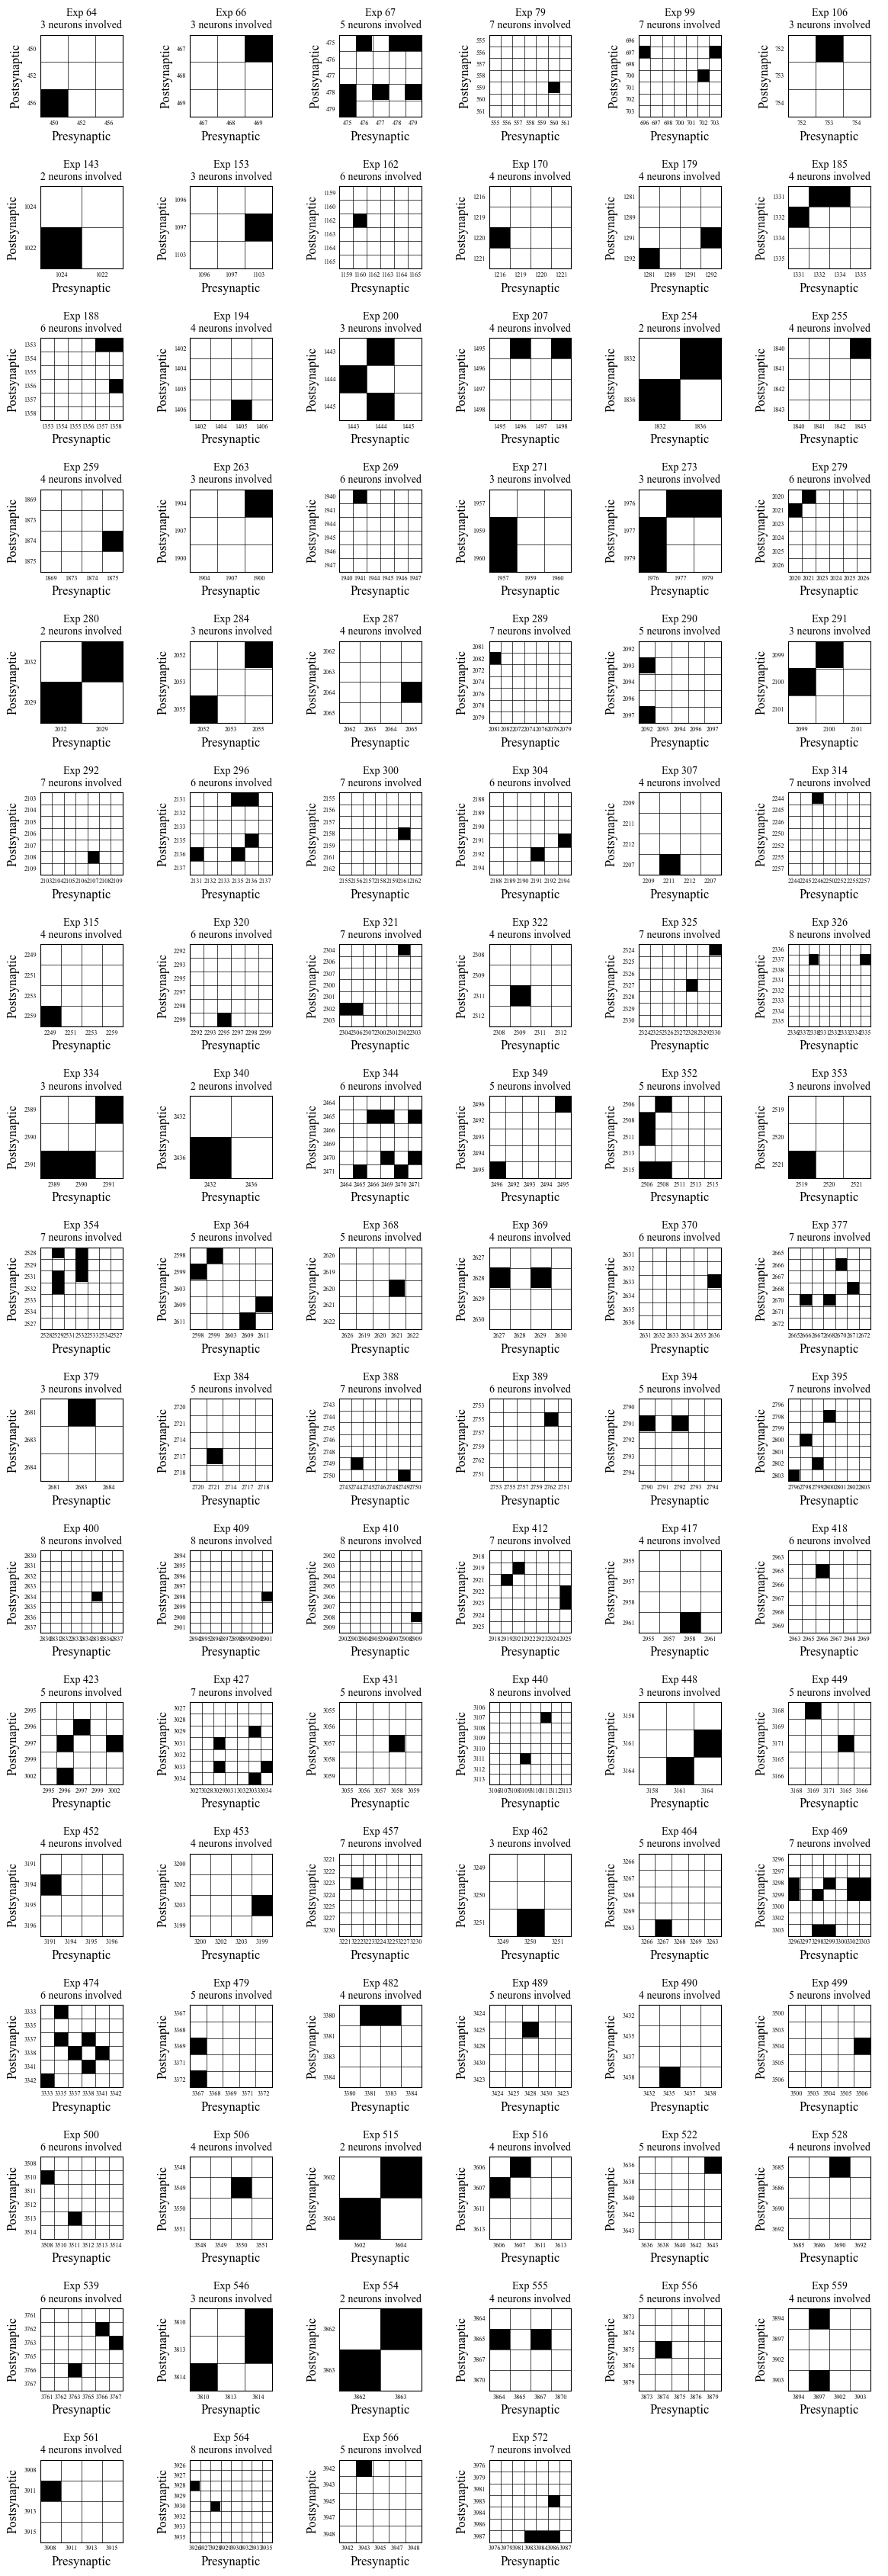

In [40]:
completed_experiments = []

# for exp in valid_experiments:
for exp in was_synapse:
    df = df_valid_experiments[(df_valid_experiments["experiment_id"]==exp)]
    pres = df["pre_cell_id"].unique().tolist()
    posts = df["post_cell_id"].unique().tolist()
    total_neurons = list(set(pres) | set(posts))
    n = len(total_neurons)
    possible_synapses = n * (n - 1)

    df_distinct_cells = df[df["pre_cell_id"] != df["post_cell_id"]]  # distinct cells in pre and post
    unique_synapses = df_distinct_cells[['pre_cell_id', 'post_cell_id']].drop_duplicates()  # drop duplicates

    if len(unique_synapses == possible_synapses):
        completed_experiments.append((exp, df, total_neurons))



# print(completed_experiments)

# Plot the first 100 valid experiments
n_max = min(100, len(completed_experiments))
n_cols = 6
n_rows = int(np.ceil(n_max / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axs = axs.flatten()

flag = 0

rows = []

# Make adjacency matrices
for i, (exp, df, total_neurons) in enumerate(completed_experiments[:n_max]):
    n = len(total_neurons)
    idx_map = {neuron: idx for idx, neuron in enumerate(total_neurons)}  # mapping neuron to index
    adj = np.zeros((n, n))

    synapses = []

    for _, row in df.iterrows():  # iterates through the dataframe
        # if row["experiment_id"] in was_not_synapse:
        #     continue
        flag += 1
        pre = row["pre_cell_id"]
        post = row['post_cell_id']
        i_pre = idx_map[pre]
        i_post = idx_map[post]
        # adj[i_pre, i_post] = 1 if row["has_synapse"] == 1 else 0 # ??????? other way around maybe
        adj[i_post, i_pre] = 1 if row["has_synapse"] == 1 else 0


    ax = axs[i]
    im = ax.imshow(adj, cmap="Greys", interpolation='none')

    # (n, n) matrix with cell centers at 0, 1, 2, ..., n-1, and cell borders at -0.5, 0.5, 1.5, ..., n-0.5
    # include minor and major ticks

    neurons = adj.shape[0]

    # Major ticks (centers)
    ax.set_xticks(np.arange(neurons))
    ax.set_yticks(np.arange(neurons))

    # Labels 0 to n-1
    # ax.set_xticklabels(np.arange(neurons))
    # ax.set_yticklabels(np.arange(neurons))

    labels = [neuron for neuron, _ in sorted(idx_map.items(), key=lambda x: x[1])]
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # ax.set_xticklabels(total_neurons)
    # ax.set_yticklabels(total_neurons)

    # Minor ticks (borders)
    ax.set_xticks(np.arange(-.5, neurons, 1), minor=True)
    ax.set_yticks(np.arange(-.5, neurons, 1), minor=True)

    # Draw grid using minor ticks
    ax.grid(which="minor", color='black', linestyle='-', linewidth=0.5)
    # Hide minor tick marks themselves
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(which="major", bottom=False, left=False)

    # neuron_ids = []

    # ax.set_title(f"Exp {exp}\n{n} neurons involved\nSynapses between: {synapses}\nTotal: {' '.join(map(str, idx_map))}", fontsize=10)
    ax.set_title(f"Exp {exp}\n{n} neurons involved", fontsize=10)
    ax.set_xlabel("Presynaptic")
    ax.set_ylabel("Postsynaptic")

    ax.set_xlim(-0.5, (neurons - 0.5))
    ax.set_ylim((neurons - 0.5), -0.5) # flipped y axis?



# Hide extra axes
for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

In [26]:
df_valid_experiments

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class
0,25,158,159,0,in,in
1,25,158,161,0,in,in
2,25,158,163,0,in,in
3,25,159,158,0,in,in
4,25,159,161,0,in,in
...,...,...,...,...,...,...
37116,5269,24845,24848,1,ex,in
37117,5269,24847,24845,0,ex,ex
37118,5269,24847,24848,0,ex,in
37119,5269,24848,24845,0,in,ex


In [28]:
df = df_valid_experiments[(df_valid_experiments["experiment_id"]==566)]

df

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class
4977,566,3942,3943,0,in,in
4984,566,3942,3945,0,in,in
4987,566,3942,3947,0,in,in
4989,566,3942,3948,0,in,in
4993,566,3943,3942,1,in,in
4996,566,3943,3945,0,in,in
4999,566,3943,3947,0,in,in
5001,566,3943,3948,0,in,in
5004,566,3945,3942,0,in,in
5005,566,3945,3943,0,in,in


# PSP

I follow the previously used requirements.
* Cell pair
    * Belong to an experiment
    * Belong to a mouse slice
    * Experiment targets VisP
    * Both cells exist
    * Both cell classes are known
    * Presynaptic cell is not mixed
* PSP amplitude
    * Not Null


PSP: magnitude of voltage change in a postsynaptic neuron, indicating excitatory (EPSP) or inhibitory (IPSP) strength

In [57]:
query = """SELECT * FROM intrinsic"""
df = pd.read_sql_query(query, con)
df


,id,cell_id,rheobase,fi_slope,input_resistance,input_resistance_ss,sag,tau,sag_peak_t,sag_depol,...,chirp_peak_ratio,chirp_peak_impedance,chirp_sync_freq,chirp_inductive_phase,isi_adapt_ratio,upstroke_adapt_ratio,downstroke_adapt_ratio,width_adapt_ratio,threshold_v_adapt_ratio,meta
0,1,22320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
1,2,22321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
2,3,22322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
3,4,22323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
4,5,9771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17935,18159,24758,NaN,NaN,6.384582e+07,6.060694e+07,0.042229,NaN,0.900203,0.239550,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
17936,18160,24761,NaN,NaN,2.476528e+07,2.894325e+07,0.045504,NaN,0.839213,0.432015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
17937,18161,24762,NaN,NaN,8.121874e+07,8.092382e+07,0.059986,NaN,0.523748,0.644732,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null
17938,18571,24815,NaN,NaN,9.230012e+07,9.277698e+07,0.037984,0.006541,0.274203,0.589737,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null


In [100]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class,
                syn.psp_amplitude,
                i_pre.fi_slope AS pre_fi_slope,
                i_post.fi_slope AS post_fi_slope

            FROM pair p


            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN synapse syn ON syn.pair_id = p.id


            WHERE 

                -- Only keep those where we have over 10 data points

                p.experiment_id IN (
                                    SELECT p.experiment_id
                                    FROM pair p
                                    GROUP BY p.experiment_id
                                    HAVING COUNT(*) > 10
                                    )

                -- Brain specs 

                AND s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- Null value filtering

                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'; 
        """

df_experiments = pd.read_sql_query(query, con)

df_experiments


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,psp_amplitude,pre_fi_slope,post_fi_slope
0,600,4138,4140,1,in,ex,-0.000204,1.105000e-12,1.131452e-13
1,600,4140,4133,1,ex,in,0.000445,1.131452e-13,8.230065e-13
2,610,4199,4201,1,ex,ex,0.000030,-1.923071e-15,7.692308e-14
3,614,4225,4227,1,in,ex,-0.000168,6.599999e-13,2.000000e-13
4,699,4698,4700,1,ex,in,0.000038,1.158730e-13,-1.269841e-14
...,...,...,...,...,...,...,...,...,...
522,4934,24346,24344,1,ex,in,0.000764,3.361344e-14,7.599999e-13
523,4935,24349,24352,1,in,in,-0.000389,4.741088e-13,3.878541e-13
524,4996,24536,24535,1,ex,in,0.001379,1.983241e-13,5.537551e-13
525,5004,24565,24564,1,in,in,-0.001123,4.807973e-13,1.739197e-13


In [102]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class,
                syn.psp_amplitude,
                i_pre.fi_slope AS pre_fi_slope,
                i_post.fi_slope AS post_fi_slope

            FROM pair p


            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id
            INNER JOIN synapse syn ON syn.pair_id = p.id


            WHERE 

                -- Brain specs 

                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- Null value filtering

                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'; 
        """

df_experiments = pd.read_sql_query(query, con)

df_experiments


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,psp_amplitude,pre_fi_slope,post_fi_slope
0,3274,18625,18622,1,in,ex,-0.000900,4.019802e-13,1.151387e-13
1,3274,18622,18625,1,ex,in,0.000104,1.151387e-13,4.019802e-13
2,2099,12325,12328,1,in,ex,-0.000097,6.614124e-13,7.454545e-13
3,1656,9804,9806,1,ex,in,0.000079,4.845483e-13,9.500002e-13
4,1656,9808,9804,1,in,ex,-0.000462,8.076025e-13,4.845483e-13
...,...,...,...,...,...,...,...,...,...
541,1636,9673,9675,1,in,ex,-0.000178,5.603319e-31,5.641526e-13
542,2326,13574,13575,1,ex,ex,0.000145,5.792521e-13,1.807065e-13
543,2793,15964,15961,1,in,in,-0.000026,1.914810e-13,3.033021e-13
544,5117,24813,24814,1,ex,in,0.000379,7.079645e-14,7.336674e-13


Text(0.5, 0, 'PSP Amplitude (mV)')

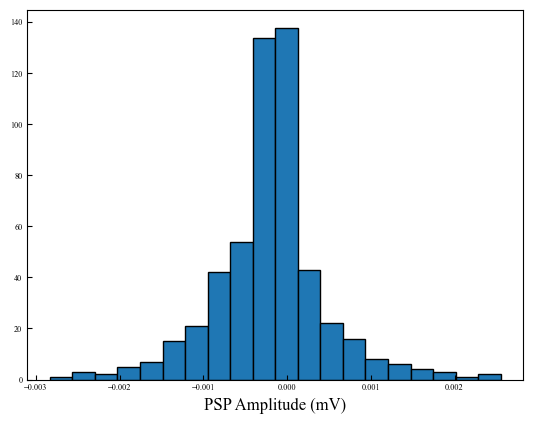

In [94]:
plt.hist(df_experiments['psp_amplitude'], bins=20, edgecolor='k')
plt.xlabel('PSP Amplitude (mV)')

In [103]:
experiment_counts = df_experiments['experiment_id'].value_counts()
valid_experiment_ids = experiment_counts[experiment_counts > 10].index
print('There are', len(valid_experiment_ids), 'experiments with more than 10 data points.')

df3 = pd.read_sql_query("SELECT * from " + str(table_list[3])[2:-3], con)
for experiment_id in valid_experiment_ids:
    region = df3[df3['id'] == experiment_id]['target_region'].values[0]
    print(f'Experiment {experiment_id} belongs to region {region}.')

There are 1 experiments with more than 10 data points.
Experiment 3172 belongs to region VisP.


In [96]:
valid_experiment_ids = df_experiments["experiment_id"].unique()
print(valid_experiment_ids)

len(valid_experiment_ids)

[ 600  610  614  699  700  727  729  731  772  779  793  850  852  865
  875  900  901 1008 1035 1036 1069 1077 1122 1124 1257 1260 1297 1329
 1331 1370 1374 1383 1436 1442 1443 1461 1471 1473 1477 1485 1486 1488
 1489 1504 1511 1512 1515 1521 1527 1544 1545 1546 1550 1556 1560 1565
 1567 1583 1587 1612 1618 1630 1632 1636 1656 1673 1676 1686 1688 1692
 1693 1705 1726 1753 1756 1759 1763 1776 1778 1787 1804 1810 1823 1839
 1841 1855 1856 1864 1866 1869 1872 1873 1896 1918 1925 1927 1932 1937
 1960 1964 1968 1969 1980 1987 2001 2007 2011 2024 2051 2057 2078 2099
 2100 2104 2111 2113 2118 2125 2127 2131 2136 2139 2147 2179 2201 2206
 2207 2211 2218 2233 2235 2244 2252 2254 2257 2258 2307 2318 2326 2341
 2342 2343 2461 2496 2498 2507 2577 2585 2590 2601 2609 2641 2646 2651
 2669 2705 2740 2742 2749 2771 2777 2783 2787 2792 2793 2804 2808 2809
 2812 2814 2820 2844 2845 2856 2858 2860 2869 2877 2878 2879 2880 2884
 2895 2903 2910 2912 2913 2917 2920 2921 2925 2929 2932 2935 2969 2970
 2972 

266

# PSP Matrix without the constraints

In [ ]:


query = """ 
            SELECT 
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post
                


            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id

            INNER JOIN synapse syn ON syn.pair_id = p.id

            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id

            -- Filter out what is relevant for us
            --WHERE

                --syn.psp_amplitude IS NOT NULL
                --AND i_pre.fi_slope IS NOT NULL
                --AND i_post.fi_slope IS NOT NULL
                --AND i_pre.fi_slope > 0
                --AND i_post.fi_slope > 0

                --p.has_synapse IS NOT NULL
                ; 
        """

df_experiments = pd.read_sql_query(query, con)

df_experiments


,experiment_id,pair_id,pre_cell_id,post_cell_id,psp_amplitude,fi_slope_pre,fi_slope_post
0,2799,88744,15996,15994,NaN,1.345974e-13,NaN
1,4603,119060,23282,23284,0.000014,NaN,NaN
2,715,30118,4778,4777,0.000953,NaN,NaN
3,4878,121773,24176,24179,NaN,2.058123e-12,7.423880e-13
4,1655,56173,9799,9797,NaN,8.190477e-13,-9.047620e-14
...,...,...,...,...,...,...,...
3275,2538,81802,14656,14660,0.000031,NaN,NaN
3276,2538,81804,14656,14662,NaN,NaN,NaN
3277,2538,81806,14657,14656,0.000271,NaN,NaN
3278,2538,81816,14658,14660,0.001185,NaN,NaN


In [107]:
experiment_counts = df_experiments['experiment_id'].value_counts()
valid_experiment_ids = experiment_counts[experiment_counts > 10].index
print('There are', len(valid_experiment_ids), 'experiments with more than 10 data points.')

df3 = pd.read_sql_query("SELECT * from " + str(table_list[3])[2:-3], con)
for experiment_id in valid_experiment_ids:
    region = df3[df3['id'] == experiment_id]['target_region'].values[0]
    print(f'Experiment {experiment_id} belongs to region {region}.')

There are 11 experiments with more than 10 data points.
Experiment 3172 belongs to region VisP.
Experiment 2698 belongs to region TCx.
Experiment 2771 belongs to region VisP.
Experiment 3228 belongs to region VisP.
Experiment 2808 belongs to region VisP.
Experiment 469 belongs to region VisP.
Experiment 1717 belongs to region TCx.
Experiment 1504 belongs to region VisP.
Experiment 4695 belongs to region VisP.
Experiment 1864 belongs to region VisP.
Experiment 3262 belongs to region VisP.


In [109]:
# Define experiments to exclude
# excluded_experiments = {469, 1504, 1864, 2218, 2808, 2913}  # why
excluded_experiments = {}

# Filter valid experiments (without excluded ones)
valid_experiments = [experiment_id for experiment_id in valid_experiment_ids if experiment_id not in excluded_experiments]

# Number of subplots
n_experiments = len(valid_experiments)
print(n_experiments)

11


In [112]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 12,             # X tick label size (8-12)
    "ytick.labelsize": 12,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [ ]:
folder = f"data_analysis/saved_data"

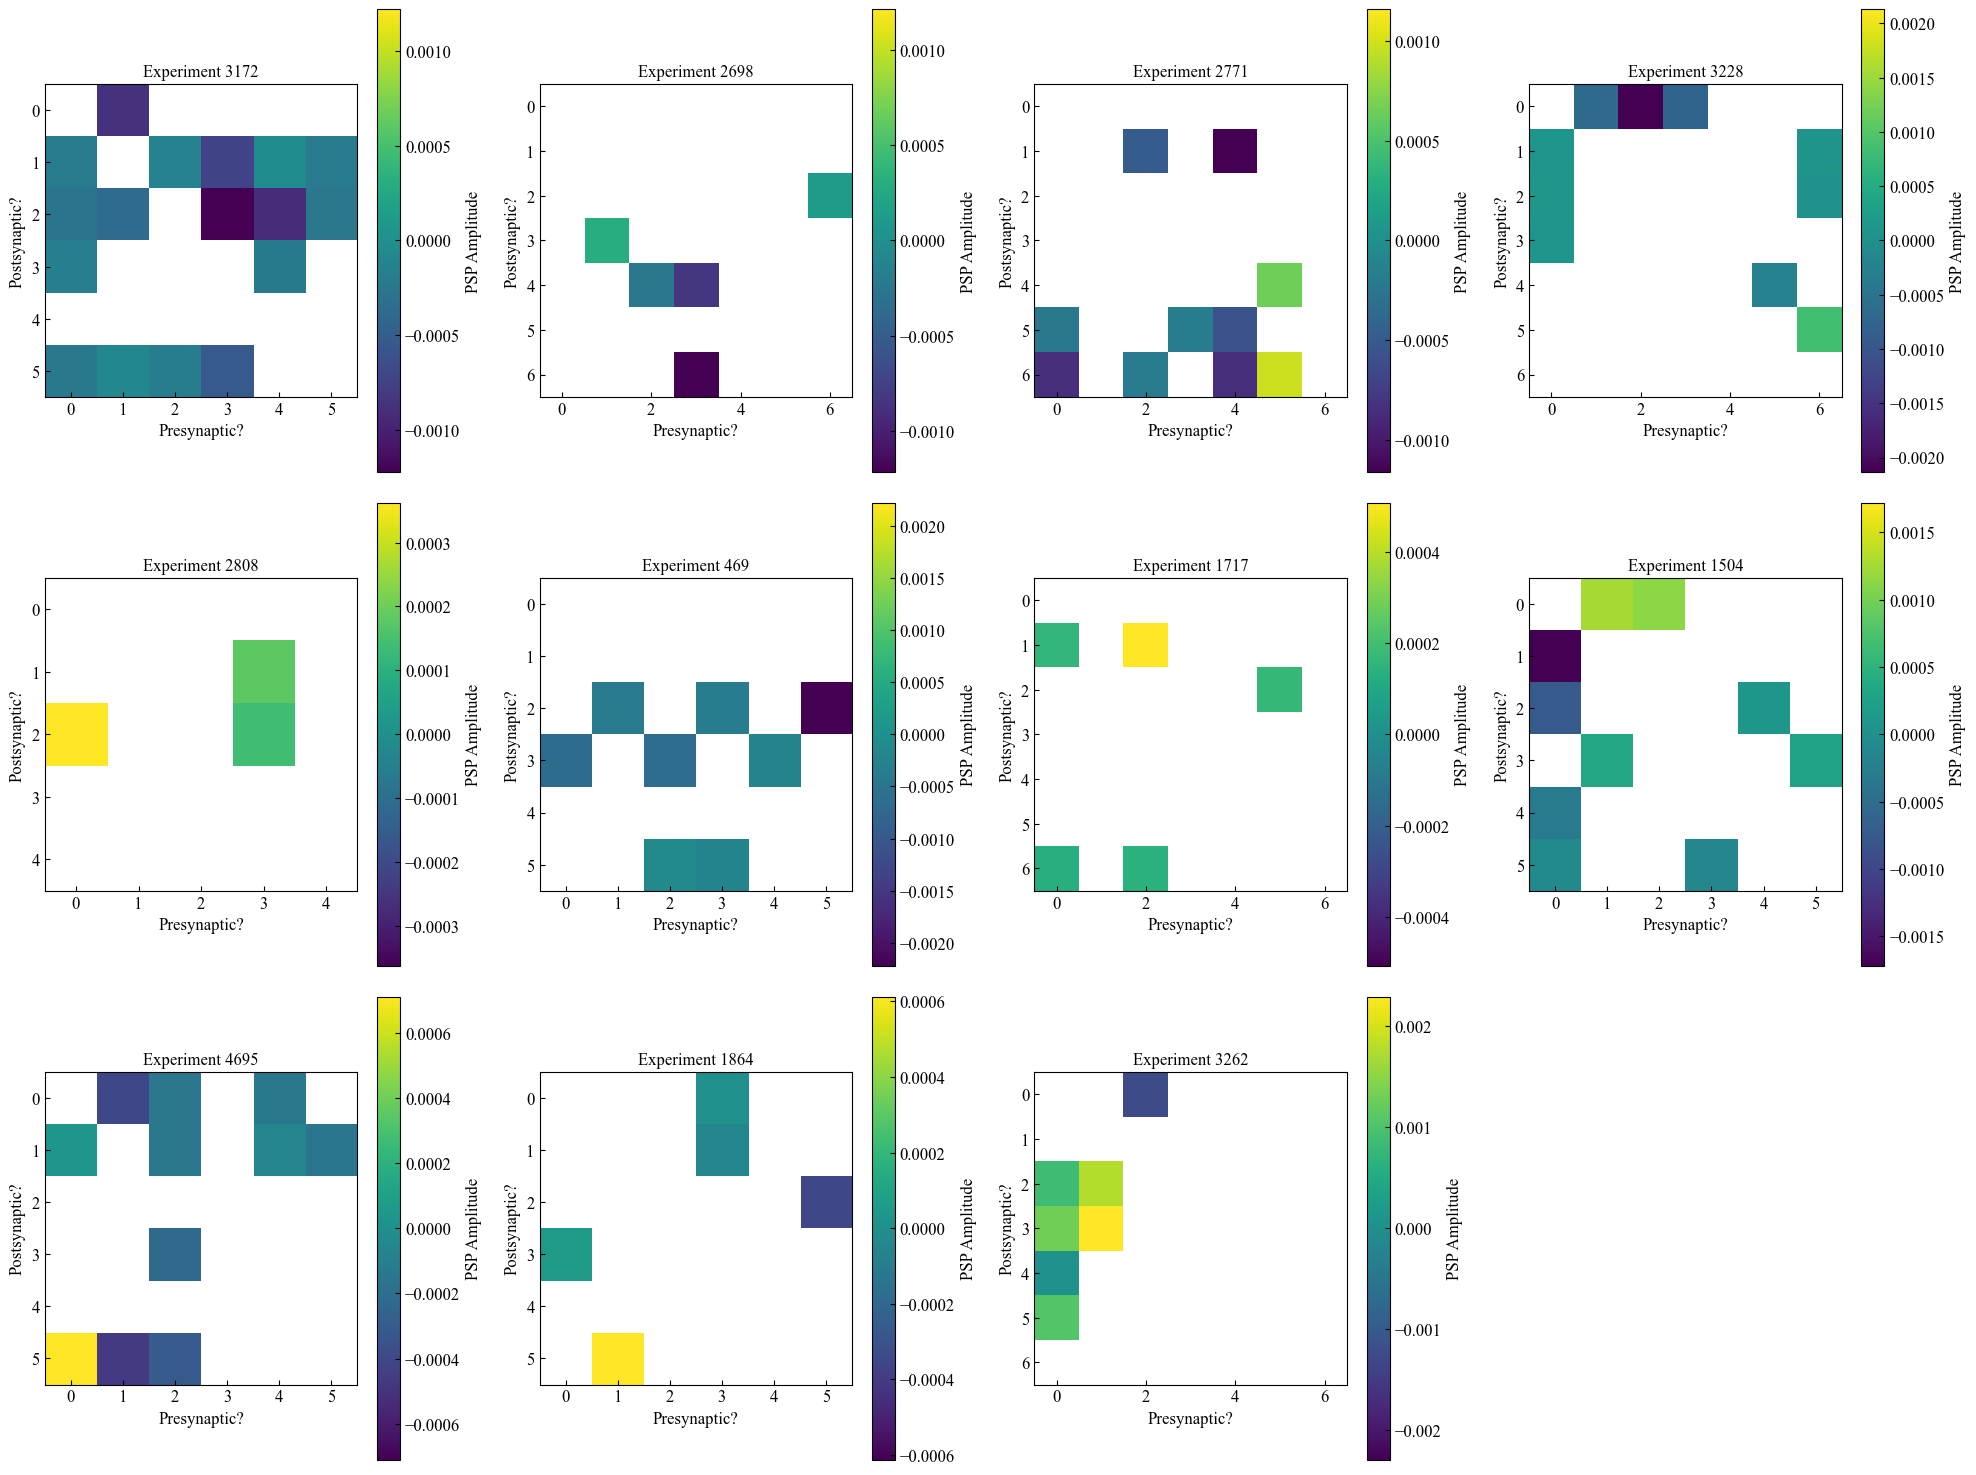

In [118]:
# Number of subplots
n_experiments = len(valid_experiment_ids)  # Should only include those with more than 10 data points

# If there are no experiments, do nothing
if n_experiments == 0:
    print("No experiments with sufficient data were found.")
else:
    # Calculate rows and columns for subplots
    n_cols = int(np.ceil(np.sqrt(n_experiments)))  # Number of columns
    n_rows = int(np.ceil(n_experiments / n_cols))  # Number of rows
    
    # Determine figure size based on number of subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

    # Flatten the axes array for easier access
    axes = axes.flatten()

    # Loop through each considered experiment
    for i, experiment_id in enumerate(valid_experiment_ids):
        df_exp = df_experiments[df_experiments['experiment_id'] == experiment_id]

        # Generate PSP matrix for the experiment
        all_cells = np.sort(pd.unique(df_exp[['pre_cell_id', 'post_cell_id']].values.ravel()))
        df_psp_matrix = pd.DataFrame(np.nan, index=all_cells, columns=all_cells)

        for _, row in df_exp.iterrows():
            pre_cell = row['pre_cell_id']
            post_cell = row['post_cell_id']
            psp_value = row['psp_amplitude']
            # df_psp_matrix.loc[pre_cell, post_cell] = psp_value
            df_psp_matrix.loc[post_cell, pre_cell] = psp_value

        df_psp_matrix.to_csv(f'saved_data/{experiment_id}_PSP_matrix.csv')

        psp_matrix_numpy = df_psp_matrix.values

        masked_psp_matrix = np.ma.masked_invalid(psp_matrix_numpy)

        # Plot the PSP matrix in the corresponding subplot
        abs_max = np.nanmax(np.abs(psp_matrix_numpy))  # Ignore NaN when calculating maximum
        im = axes[i].imshow(masked_psp_matrix, cmap='viridis', interpolation='none', vmin=-abs_max, vmax=abs_max)
        axes[i].set_title(f'Experiment {experiment_id}')
        plt.colorbar(im, ax=axes[i], label='PSP Amplitude')

        axes[i].set_xlabel(f"Presynaptic?")
        axes[i].set_ylabel(f"Postsynaptic?")



    # Remove empty axes if there are fewer experiments than subplots
    for j in range(n_experiments, len(axes)):
        axes[j].axis('off')
        axes[j].set_xticks([])
        axes[j].set_yticks([])

    # Adjust subplots
    plt.tight_layout()
    plt.show()


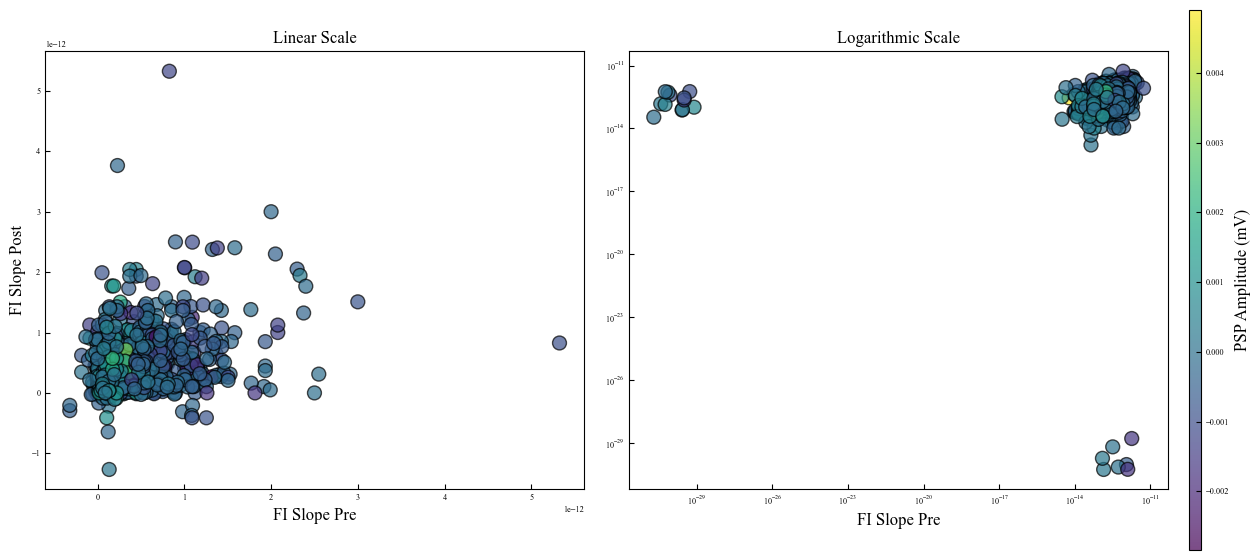

In [108]:
df_filtered = df_experiments.copy()

# Create the figure with two subplots without shared axes
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First plot with linear scale
sc1 = axs[0].scatter(df_filtered['fi_slope_pre'], df_filtered['fi_slope_post'], 
                      c=np.log1p(df_filtered['psp_amplitude']), cmap='viridis', edgecolors='k', 
                      s=100, alpha=0.7)

axs[0].set_xlabel('FI Slope Pre')
axs[0].set_ylabel('FI Slope Post')
axs[0].set_title('Linear Scale')

# Second plot with logarithmic scale
sc2 = axs[1].scatter(df_filtered['fi_slope_pre'], df_filtered['fi_slope_post'], 
                      c=np.log1p(df_filtered['psp_amplitude']), cmap='viridis', edgecolors='k', 
                      s=100, alpha=0.7)
axs[1].set_xlabel('FI Slope Pre')
axs[1].set_title('Logarithmic Scale')
axs[1].set_xscale('log')
axs[1].set_yscale('log')

# Adjust the layout to leave space at the top
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Create an additional axis for the colorbar at the top
cbar_ax = fig.add_axes([1, 0, 0.01, 0.9])
cbar = fig.colorbar(sc1, cax=cbar_ax, orientation='vertical')
cbar.set_label('PSP Amplitude (mV)')

plt.show()




# KMeans

## Without data transformation

In [123]:
from sklearn.cluster import KMeans

In [128]:


query = """ 
            SELECT 
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post
                


            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id

            INNER JOIN synapse syn ON syn.pair_id = p.id

            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id

            -- Filter out what is relevant for us
            WHERE
                i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL

                --AND i_pre.fi_slope > 0
                --AND i_post.fi_slope > 0

                --p.has_synapse IS NOT NULL
                ; 
        """

df_experiments = pd.read_sql_query(query, con)

df_experiments


,experiment_id,pair_id,pre_cell_id,post_cell_id,psp_amplitude,fi_slope_pre,fi_slope_post
0,3271,102624,18608,18612,0.004912,5.952383e-15,2.881222e-13
1,3270,102619,18606,18607,0.000393,2.085229e-13,9.777069e-14
2,3274,102709,18625,18622,-0.000900,4.019802e-13,1.151387e-13
3,3502,108220,19758,19760,0.000111,2.379171e-13,7.093534e-14
4,3274,102675,18622,18625,0.000104,1.151387e-13,4.019802e-13
...,...,...,...,...,...,...,...
809,2326,76208,13574,13575,0.000145,5.792521e-13,1.807065e-13
810,2793,88588,15964,15961,-0.000026,1.914810e-13,3.033021e-13
811,5105,123616,24778,24781,-0.000198,8.018796e-13,9.525691e-14
812,5117,123712,24813,24814,0.000379,7.079645e-14,7.336674e-13


c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


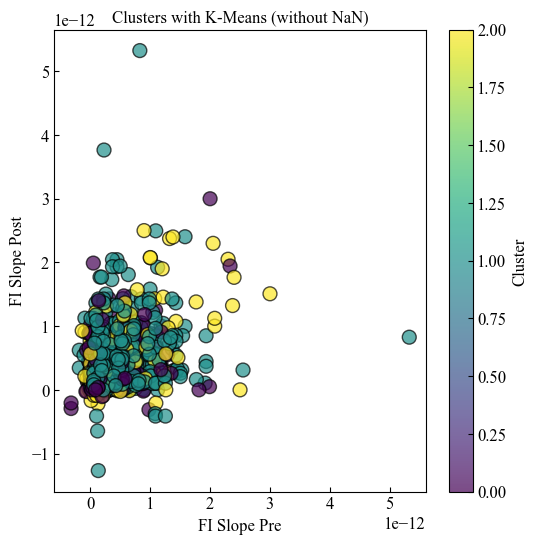

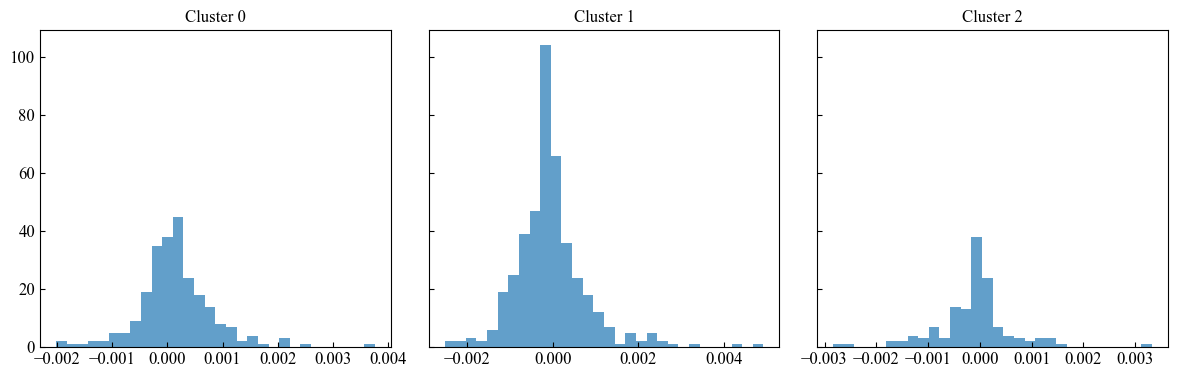

In [130]:
# Possible fix to threading warning
import os
os.environ["OMP_NUM_THREADS"] = "4"

# KMeans
from sklearn.cluster import KMeans

# KMeans: Each point is assigned to nearest center (cluster "means")
# Nearest neighbor
# Update
# Repeat until convergence

# Select the columns needed for clustering

df_no_nan = df_experiments.copy()

# Convert to numpy array for K-Means
X = df_no_nan.values

# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

# Create a 'cluster' column in df_no_nan
df_no_nan['cluster'] = kmeans.labels_

df_result_exclude = df_no_nan.copy()
df_result_exclude['cluster'] = None
df_result_exclude.loc[df_no_nan.index, 'cluster'] = df_no_nan['cluster']

# Plot to verify
plt.figure(figsize=(6, 6))
sc = plt.scatter(
    df_no_nan['fi_slope_pre'], 
    df_no_nan['fi_slope_post'], 
    c=df_no_nan['cluster'], 
    cmap='viridis', 
    edgecolors='k', 
    s=100, 
    alpha=0.7
)

plt.xlabel('FI Slope Pre')
plt.ylabel('FI Slope Post')
plt.title('Clusters with K-Means (without NaN)')
plt.colorbar(sc, label='Cluster')
plt.show()

# Finally, make histograms of psp_amplitude for each cluster
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i in range(3):
    cluster_data = df_result_exclude[df_result_exclude['cluster'] == i]
    axs[i].hist(cluster_data['psp_amplitude'], bins=30, alpha=0.7)
    axs[i].set_title(f'Cluster {i}')

plt.tight_layout()
plt.show()



## With data transformation

In [132]:
query = """ 
            SELECT 
                p.experiment_id,
                p.id AS pair_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                syn.psp_amplitude,
                i_pre.fi_slope AS fi_slope_pre,
                i_post.fi_slope AS fi_slope_post
                


            FROM pair p

            INNER JOIN experiment e ON e.id = p.experiment_id

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id

            INNER JOIN synapse syn ON syn.pair_id = p.id

            INNER JOIN intrinsic i_pre ON p.pre_cell_id = i_pre.cell_id
            INNER JOIN intrinsic i_post ON p.post_cell_id = i_post.cell_id

            -- Filter out what is relevant for us
            WHERE
                i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                AND syn.psp_amplitude IS NOT NULL

                AND i_pre.fi_slope > 0
                AND i_post.fi_slope > 0

                --p.has_synapse IS NOT NULL
                ; 
        """

df = pd.read_sql_query(query, con)

df


,experiment_id,pair_id,pre_cell_id,post_cell_id,psp_amplitude,fi_slope_pre,fi_slope_post
0,3271,102624,18608,18612,0.004912,5.952383e-15,2.881222e-13
1,3270,102619,18606,18607,0.000393,2.085229e-13,9.777069e-14
2,3274,102709,18625,18622,-0.000900,4.019802e-13,1.151387e-13
3,3502,108220,19758,19760,0.000111,2.379171e-13,7.093534e-14
4,3274,102675,18622,18625,0.000104,1.151387e-13,4.019802e-13
...,...,...,...,...,...,...,...
731,2326,76208,13574,13575,0.000145,5.792521e-13,1.807065e-13
732,2793,88588,15964,15961,-0.000026,1.914810e-13,3.033021e-13
733,5105,123616,24778,24781,-0.000198,8.018796e-13,9.525691e-14
734,5117,123712,24813,24814,0.000379,7.079645e-14,7.336674e-13


c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\snrambo\AppData\Local\Temp\ipykernel_16596\736009250.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(clusters))


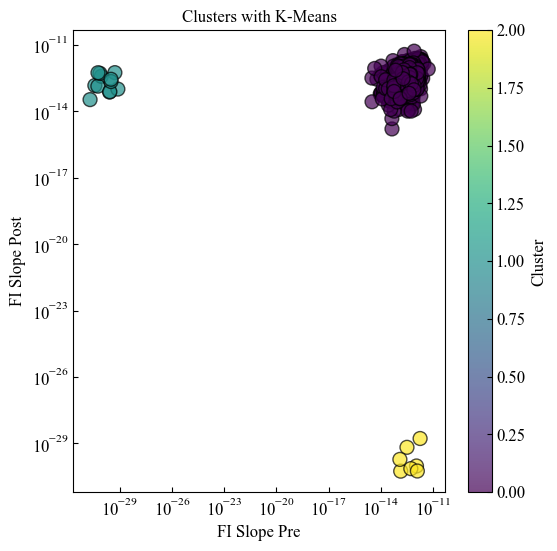

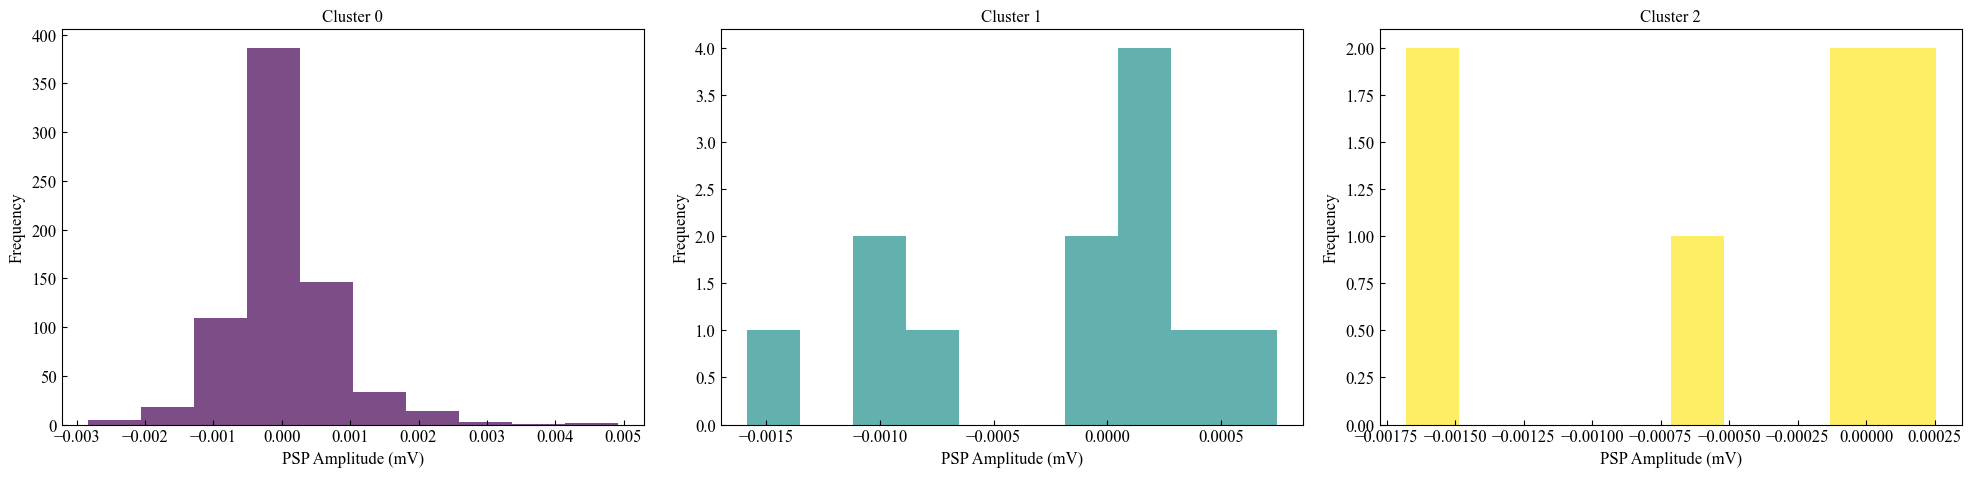

In [134]:
# Possible fix to threading warning
import os
os.environ["OMP_NUM_THREADS"] = "4"

# KMeans
from sklearn.cluster import KMeans

# KMeans: Each point is assigned to nearest center (cluster "means")
# Nearest neighbor
# Update
# Repeat until convergence
import matplotlib.cm as cm

df_experiments = df.copy()

# 2) Create logarithmic version of fi_slope_pre and fi_slope_post
df_clean_log = df_experiments[['fi_slope_pre', 'fi_slope_post']].apply(np.log10)

# 3) Apply K-Means on logarithmic data
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df_clean_log)

# Save the cluster labels in the original DataFrame (df_clean)
df_experiments['cluster'] = kmeans.labels_

# Get unique clusters
clusters = sorted(df_experiments['cluster'].unique())

# Get the colormap used in the scatter plot
cmap = cm.get_cmap('viridis', len(clusters))
colors = [cmap(i) for i in range(len(clusters))]

# 4) Plot in log scale on axes
plt.figure(figsize=(6, 6))
sc = plt.scatter(
    df_experiments['fi_slope_pre'], 
    df_experiments['fi_slope_post'], 
    c=df_experiments['cluster'], 
    cmap='viridis', 
    edgecolors='k', 
    s=100, 
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('FI Slope Pre')
plt.ylabel('FI Slope Post')
plt.title('Clusters with K-Means')
cbar = plt.colorbar(sc)
cbar.set_label('Cluster')
plt.show()

# Create a subplot for each cluster
fig, axs = plt.subplots(1, len(clusters), figsize=(20, 5))

for i, cl in enumerate(clusters):
    # Select data from cluster i
    cluster_data = df_experiments[df_experiments['cluster'] == cl]['psp_amplitude']
    axs[i].hist(cluster_data, alpha=0.7, color=colors[i])
    axs[i].set_title(f'Cluster {cl}')
    axs[i].set_xlabel('PSP Amplitude (mV)')
    axs[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [20]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING num_synapses != 0;
        """

df_onlysynapse = pd.read_sql_query(query, con)

df_onlysynapse

,experiment_id,total_pairs,num_synapses,num_no_synapses
0,64,6,1,5
1,66,6,1,5
2,67,20,7,13
3,79,42,1,41
4,99,42,3,39
...,...,...,...,...
1081,5264,12,1,11
1082,5265,6,4,2
1083,5266,1,1,0
1084,5268,2,1,1


In [19]:
print(1086 + 1355)

2441


To look for where it is above some number of synapses we can use having:

In [57]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING num_synapses > 10;
        """

df_synapses = pd.read_sql_query(query, con)

df_synapses


,experiment_id,total_pairs,num_synapses,num_no_synapses
0,1504,42,11,31
1,1864,30,11,19
2,2771,30,11,19
3,2808,20,12,8
4,3172,56,19,37
5,3228,30,12,18
6,3262,42,11,31


#### Debugging row differences with the other version

**Subtract differences too see why I get less rows**

In [ ]:
df_slice = pd.read_sql_query("SELECT * from "+ str(table_list[2])[2:-3], con)
df_experiment = pd.read_sql_query("SELECT * from "+ str(table_list[3])[2:-3], con)
df_cell = pd.read_sql_query("SELECT * from "+ str(table_list[7])[2:-3], con)
df_pair = pd.read_sql_query("SELECT * from "+ str(table_list[9])[2:-3], con)


# Obtener los experimentos en df2 que son de ratón
######## Get the experiments in df_2 = df_slice that are mouse
mouse_ids = df_slice[df_slice['species'] == 'mouse']['id']

# Obtener los experimentos en df3 que tienen target_region == VISp
######## Get the experiments in df_3 = df_experiment that have target_region == VISp
visp_ids = df_experiment[df_experiment['target_region'] == 'VisP']['id']
print(visp_ids)

# Intersección de ambos conjuntos de experimentos
######## Intersection of both sets of experiments
valid_exp_ids = set(mouse_ids).intersection(set(visp_ids))

# Filtrar df9 con esos experimentos válidos
######## Filter df9 = df_pair with those valid experiments
df_pair_2 = df_pair[df_pair['experiment_id'].isin(mouse_ids)]


df_merged = pd.merge(df_pair[['id', 'experiment_id', 'has_synapse', 'pre_cell_id', 'post_cell_id']],
                     df_cell[['id', 'cell_class']],
                     left_on='pre_cell_id', right_on='id')
df_merged.rename(columns={'cell_class': 'pre_cell_class'}, inplace=True)

# Seleccionamos y ordenamos las columnas deseadas
df_result = df_merged[['experiment_id','pre_cell_id', 'post_cell_id', 'has_synapse', 'pre_cell_class']]
df_result = df_result[df_result['pre_cell_class']!= 'mixed']

# Merge adicional entre post_cell_id y id en df7
df_result = pd.merge(df_result,
                     df_cell[['id', 'cell_class']],
                     left_on='post_cell_id', right_on='id',
                     suffixes=('_pre', '_post'))

# Filtramos los resultados para que los 'pre_cell_class' no sean 'mixed'
df_result = df_result[df_result['pre_cell_class'] != 'mixed']

# Si quieres cambiar el nombre de la columna 'cell_class_post' por ejemplo, puedes hacerlo de la siguiente manera:
df_result.rename(columns={'cell_class': 'post_cell_class'}, inplace=True)


df_result = df_result[['experiment_id','pre_cell_id', 'post_cell_id', 'has_synapse', 'pre_cell_class', 'post_cell_class']]
df_clean = df_result.dropna(subset=['pre_cell_class', 'post_cell_class', 'has_synapse'])

# display(df_clean)

df_check = df_clean.merge(
    df_experiment[['id', 'target_region']],
    left_on='experiment_id',
    right_on='id',
    how='left'
)

print("checking")
df_check['target_region'].value_counts()

#### TEST: Other regions were included

df_check = df_clean.merge(
    df_experiment[['id', 'target_region']],
    left_on='experiment_id',
    right_on='id',
    how='left'
)

print("checking")
df_check['target_region'].value_counts()

0          1
1          2
2          3
3          4
4          5
        ... 
5053    5265
5054    5266
5055    5267
5056    5268
5057    5269
Name: id, Length: 4369, dtype: int64
checking


target_region
VisP    37127
TCx      2573
          213
FCx       166
ALM        90
PCx        85
TEa        30
Name: count, dtype: int64